<a href="https://colab.research.google.com/github/DrTkachuk/RobustnessOfTensegrityFormFindingViaRankMinimization/blob/main/TensegrityExample5_12node_spatial_with_22members.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook implements an example 5

Reproduces eq (51)

Tkachuk, A. (2022). Robustness of rank minimization heuristics for form-finding of tensegrity structures. Computers & Structures, 266, 106786.

In [1]:
import numpy as np
from numpy.linalg import matrix_rank
import cvxpy as cp

In [2]:
# Input
nele = 22
nnode = 12
# connectivity matrix
ID = np.array([[1, 5], [2, 7], [3, 9], [4, 11], [1, 6],   [2, 8], [3, 10], [4, 12], [5, 7], [7, 9],  [9, 11], [11, 5], [6, 8], [8, 10], [10, 12],  [12, 6], [5, 6], [7, 8], [9, 10], [11, 12],   [1, 3], [2, 4] ])
print(ID)
# dummy flag for vizualization - 1 means green dashed line or dummy truss
dummyflag = np.array([0, 0, 0, 0, 0,  0, 0, 0, 0, 0,  0, 0, 0, 0, 0,  0, 0, 0, 0, 0, 1, 1])
# sign of force densities: +1 - cabel/tension; -1 - compression
SigM = np.diag([1,1,1,1,1, 1,1,1,1,1, 1,1,1,1,1,1, -1,-1,-1,-1,-1,-1])
print(dummyflag)
#prescribed nodal location, here nodes 1,2,11,12
xbar=np.array([0.0,10.0,2.5,2.5])
ybar=np.array([0.0,0.0,7.5,7.5])
zbar=np.array([0.0,0.0,2.0,-2.0])
#sign offset for the force densities
epsilon=0.01
#parameter of log-det heuristics
delta=0.000001
num_iter=5
#tolerance for rank definition
rank_tol = 1e-7

[[ 1  5]
 [ 2  7]
 [ 3  9]
 [ 4 11]
 [ 1  6]
 [ 2  8]
 [ 3 10]
 [ 4 12]
 [ 5  7]
 [ 7  9]
 [ 9 11]
 [11  5]
 [ 6  8]
 [ 8 10]
 [10 12]
 [12  6]
 [ 5  6]
 [ 7  8]
 [ 9 10]
 [11 12]
 [ 1  3]
 [ 2  4]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1]


In [3]:
#node-edge incidence matrix
C = np.zeros((nnode,nele))
for i in range(nele):
    C[ID[i,0]-1,i] = -1
    C[ID[i,1]-1,i] = 1
print(C)

[[-1.  0.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0. -1.  0.]
 [ 0. -1.  0.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0. -1.]
 [ 0.  0. -1.  0.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  1.  0.]
 [ 0.  0.  0. -1.  0.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  1.]
 [ 1.  0.  0.  0.  0.  0.  0.  0. -1.  0.  0.  1.  0.  0.  0.  0. -1.  0.
   0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0. -1.  0.  0.  1.  1.  0.
   0.  0.  0.  0.]
 [ 0.  1.  0.  0.  0.  0.  0.  0.  1. -1.  0.  0.  0.  0.  0.  0.  0. -1.
   0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  1. -1.  0.  0.  0.  1.
   0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.  0.  0.  0.  1. -1.  0.  0.  0.  0.  0.  0.  0.
  -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  1. -1.  0.  0.  0.
   1.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  1. -1.  0.  0.  0.  0.  0. 

In [4]:
# definition of cvxpy problem
# force densities are the only variables
Q = cp.Variable(nele)

# initialization of weighting matrix
W = np.eye(nnode,nnode)
#rank history
rank_hist=[]

for i in range(num_iter):
    # definition of cost and constraints
    cost=cp.trace(W @ C @ cp.diag(Q) @ C.T)
    constraints = [epsilon <= SigM @ Q, cp.PSD(C @ cp.diag(Q) @ C.T)]
    # creating problem object
    prob = cp.Problem(cp.Minimize(cost), constraints=constraints)
    prob.solve()
    #history of rank change
    rank_hist.append(int(matrix_rank (C @ np.diag(Q.value) @ C.T, tol=rank_tol, hermitian=True)))
    #updating the weight
    W =np.linalg.inv( C @ np.diag(Q.value) @ C.T + delta * np.eye(nnode,nnode))

print(Q.value/epsilon)
print(rank_hist)




[ 2.00000001  2.00000001  2.00000001  2.00000001  2.00000001  2.00000001
  2.00000001  2.00000001  1.          1.          1.          1.
  1.          1.          1.          1.         -1.         -1.
 -1.         -1.         -1.         -1.        ]
[8, 8, 8, 8, 8]


In [5]:
rank_achieved= matrix_rank (C @ np.diag(Q.value) @ C.T, tol=rank_tol, hermitian=True)

In [6]:
# recovery of the geometry from the nullspace of the force density matrix
# first, full SVD decompostion
U, S, Vh = np.linalg.svd(C @ np.diag(Q.value) @ C.T, full_matrices=True,hermitian=True)

In [7]:
#slicing the vectors and finding equations
phi = U[:,(nnode-4):nnode]
Kgeom=phi[[0, 1, 10, 11],:]
# finding the nodal position as linear combination of the nulspace vectors
alpha = np.linalg.solve(Kgeom,xbar)
beta = np.linalg.solve(Kgeom,ybar)
gamma = np.linalg.solve(Kgeom,zbar)
# final vector of nodal positions
xstar= phi @ alpha
ystar= phi @ beta
zstar= phi @ gamma
print(xstar)
print(ystar)
print(zstar)

[-9.99200722e-16  1.00000000e+01  1.00000000e+01  1.20076802e-08
  2.49999999e+00  2.49999999e+00  7.50000001e+00  7.50000001e+00
  7.50000002e+00  7.50000002e+00  2.50000000e+00  2.50000000e+00]
[-8.04911693e-16  8.88178420e-16  9.99999999e+00  9.99999999e+00
  2.49999999e+00  2.49999999e+00  2.49999999e+00  2.49999999e+00
  7.50000000e+00  7.50000000e+00  7.50000000e+00  7.50000000e+00]
[-5.29395592e-23 -1.33176079e-22 -2.00523731e-14  4.65043063e-15
  2.00000000e+00 -2.00000000e+00  2.00000000e+00 -2.00000000e+00
  2.00000000e+00 -2.00000000e+00  2.00000000e+00 -2.00000000e+00]


In [8]:
#check recovering geometry to fullfil the homogeneous equilibrium conditions
print(np.linalg.norm(C @ np.diag(Q.value) @ C.T @ xstar))
print(np.linalg.norm(C @ np.diag(Q.value) @ C.T @ ystar))

4.1802216349350355e-11
4.1802059130627807e-11


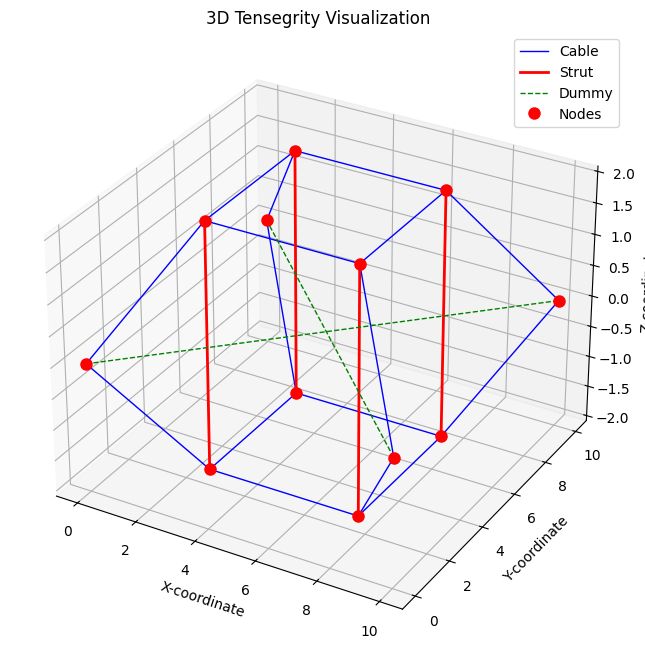

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

cable_label_added = False
strut_label_added = False
dummy_label_added = False

for i in range(nele):
    node1 = ID[i, 0] - 1  # Adjust for 0-based indexing
    node2 = ID[i, 1] - 1  # Adjust for 0-based indexing

    x_coords = [xstar[node1], xstar[node2]]
    y_coords = [ystar[node1], ystar[node2]]
    z_coords = [zstar[node1], zstar[node2]]

    if SigM[i,i] == 1:
        label = 'Cable' if not cable_label_added else ''
        ax.plot(x_coords, y_coords, z_coords, 'b-', linewidth=1, label=label)
        cable_label_added = True
    elif dummyflag[i] == 0:
        label = 'Strut' if not strut_label_added else ''
        ax.plot(x_coords, y_coords, z_coords, 'r-', linewidth=2, label=label)
        strut_label_added = True
    else:
        label = 'Dummy' if not dummy_label_added else ''
        ax.plot(x_coords, y_coords, z_coords, 'g--', linewidth=1, label=label)
        dummy_label_added = True

# Plot nodes
ax.plot(xstar, ystar, zstar, 'ro', markersize=8, label='Nodes')

ax.set_xlabel('X-coordinate')
ax.set_ylabel('Y-coordinate')
ax.set_zlabel('Z-coordinate')
ax.set_title('3D Tensegrity Visualization')
ax.legend()
plt.grid(True)
plt.show()